# Teil 2: Datenbeschreibung und Vorbereitung

In diesem Notebook wird der Handball-Datensatz geladen, kontrolliert und für die spätere Machine-Learning-Modellierung vorbereitet. Dabei werden eine Zielvariable ausgewählt, statistische Kennzahlen berechnet, Grafiken erstellt und numerische Merkmale skaliert.


## 1. Bibliotheken importieren

Für die Analyse werden `pandas`, `matplotlib` und `sklearn` verwendet. `openpyxl` wird benötigt, damit Excel-Dateien gelesen werden können.


In [1]:
try:
    import openpyxl
except ImportError:
    import sys
    !{sys.executable} -m pip install openpyxl

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", None)


Matplotlib is building the font cache; this may take a moment.


## 2. Datensatz laden

Die Datei `LB.xlsx` muss im gleichen Ordner wie dieses Notebook liegen. Auf GitHub sollte diese Datei ebenfalls hochgeladen sein, damit das Notebook von der Lehrperson ausgeführt werden kann.


In [2]:
data_path = "LB.xlsx"

df = pd.read_excel(data_path, engine="openpyxl")

print(f"Anzahl Zeilen: {df.shape[0]}")
print(f"Anzahl Spalten: {df.shape[1]}")
display(df.head())


Anzahl Zeilen: 5825
Anzahl Spalten: 20


,Lastname,Name,Team,Position,Games Played,Goals,Missed,Field Goals,Penalty Goals,Shooting Accuracy,Assists,Technical Faults,Steals,Blocks,Yellow Cards,2 Min Exclusion,Red Cards,Blue Cards,Season,Tier
0,Savvas,Savvas,HIL,LB,36,289,195,210,79,5971,52,40,7,7,20,16,1,0,17/18,B
1,Gunnarsson,Arnor Thor,BHC,RW,38,275,93,163,112,7473000000000001,14,17,11,0,2,3,0,0,17/18,B
2,Smits,Kay,WHV,RB,37,258,141,178,80,6466,90,74,20,4,5,10,0,0,17/18,B
3,Kaletsch,Paul,KON,LB,35,251,194,142,109,564,74,62,4,6,13,12,0,0,17/18,B
4,Billek,Florian,COB,RW,37,243,98,132,111,7126,24,29,20,0,4,2,0,0,17/18,B


In [3]:
print("Spalten im Datensatz:")
for column in df.columns:
    print("-", column)


Spalten im Datensatz:
- Lastname
- Name
- Team
- Position
- Games Played
- Goals
- Missed
- Field Goals
- Penalty Goals
- Shooting Accuracy
- Assists
- Technical Faults
- Steals
- Blocks
- Yellow Cards
- 2 Min Exclusion
- Red Cards
- Blue Cards
- Season
- Tier


## 3. Datenqualität prüfen

Hier wird geprüft, ob fehlende Werte vorhanden sind und welche Datentypen die einzelnen Spalten besitzen. Das hilft zu entscheiden, welche Felder direkt für Berechnungen und Machine Learning verwendet werden können.


In [4]:
print("Datentypen:")
display(df.dtypes.to_frame("Datentyp"))

print("Fehlende Werte pro Spalte:")
display(df.isna().sum().to_frame("Fehlende Werte"))


Datentypen:


,Datentyp
Lastname,object
Name,object
Team,object
Position,object
Games Played,int64
Goals,int64
Missed,int64
Field Goals,int64
Penalty Goals,int64
Shooting Accuracy,int64


Fehlende Werte pro Spalte:


,Fehlende Werte
Lastname,0
Name,5
Team,0
Position,0
Games Played,0
Goals,0
Missed,0
Field Goals,0
Penalty Goals,0
Shooting Accuracy,0


## 4. Zielvariable auswählen

In diesem Projekt soll **`Goals`** als Zielvariable verwendet werden. Das Ziel ist also, später vorherzusagen, wie viele Tore ein Spieler erzielt. Diese Zielvariable ist sinnvoll, weil die Anzahl Tore mit verschiedenen anderen Feldern zusammenhängen kann, zum Beispiel mit gespielten Spielen, Assists, Position, technischen Fehlern und weiteren Leistungsdaten.

Die Spalte **`Shooting Accuracy`** wird in dieser Analyse nicht als ML-Merkmal verwendet, weil die Werte im Datensatz teilweise unplausibel formatiert sind und dadurch die Auswertung verfälschen könnten.


In [5]:
target_column = "Goals"
excluded_columns = ["Shooting Accuracy"]

numeric_cols = [
    column for column in df.select_dtypes(include="number").columns
    if column not in excluded_columns
]

feature_cols = [
    column for column in numeric_cols
    if column != target_column
]

print("Zielvariable:", target_column)
print("Ausgeschlossene Spalten:", excluded_columns)
print("Numerische Spalten für die Analyse:", numeric_cols)
print("Numerische Feature-Spalten für spätere Modelle:", feature_cols)


Zielvariable: Goals
Ausgeschlossene Spalten: ['Shooting Accuracy']
Numerische Spalten für die Analyse: ['Games Played', 'Goals', 'Missed', 'Field Goals', 'Penalty Goals', 'Assists', 'Technical Faults', 'Steals', 'Blocks', 'Yellow Cards', '2 Min Exclusion', 'Red Cards', 'Blue Cards']
Numerische Feature-Spalten für spätere Modelle: ['Games Played', 'Missed', 'Field Goals', 'Penalty Goals', 'Assists', 'Technical Faults', 'Steals', 'Blocks', 'Yellow Cards', '2 Min Exclusion', 'Red Cards', 'Blue Cards']


## 5. Statistische Kennzahlen

Für alle numerischen Felder werden wichtige statistische Kennzahlen berechnet. Dazu gehören Anzahl Werte, Mittelwert, Median, Standardabweichung, Minimum und Maximum.


In [6]:
numeric_statistics = df[numeric_cols].agg(["count", "mean", "median", "std", "min", "max"]).T
numeric_statistics = numeric_statistics.round(2)
display(numeric_statistics)


,count,mean,median,std,min,max
Games Played,5825.0,23.00,27.0,12.14,1.0,38.0
Goals,5825.0,42.56,25.0,49.04,0.0,289.0
Missed,5825.0,26.62,15.0,32.49,0.0,224.0
Field Goals,5825.0,37.93,24.0,41.41,0.0,248.0
Penalty Goals,5825.0,4.62,0.0,15.74,0.0,143.0
Assists,5825.0,15.42,5.0,23.76,0.0,210.0
Technical Faults,5825.0,11.78,6.0,14.96,0.0,101.0
Steals,5825.0,3.14,1.0,4.35,0.0,35.0
Blocks,5825.0,3.10,0.0,6.44,0.0,59.0
Yellow Cards,5825.0,2.65,1.0,4.30,0.0,27.0


Zusätzlich werden die wichtigsten Informationen zu den Textspalten angezeigt. Dazu gehören die Anzahl unterschiedlicher Werte und der häufigste Wert pro Spalte.


In [7]:
categorical_cols = df.select_dtypes(exclude="number").columns.tolist()

categorical_summary = pd.DataFrame({
    "Anzahl unterschiedliche Werte": df[categorical_cols].nunique(),
    "Häufigster Wert": [df[column].mode(dropna=True).iloc[0] if not df[column].mode(dropna=True).empty else None for column in categorical_cols]
})

display(categorical_summary)


,Anzahl unterschiedliche Werte,Häufigster Wert
Lastname,1760,Schmidt
Name,782,Tim
Team,48,BER
Position,7,LB
Season,7,22/23
Tier,2,B


## 6. Grafiken

Die erste Grafik zeigt den Zusammenhang zwischen gespielten Spielen und Toren. Dadurch kann geprüft werden, ob Spieler mit mehr Einsätzen tendenziell auch mehr Tore erzielen.


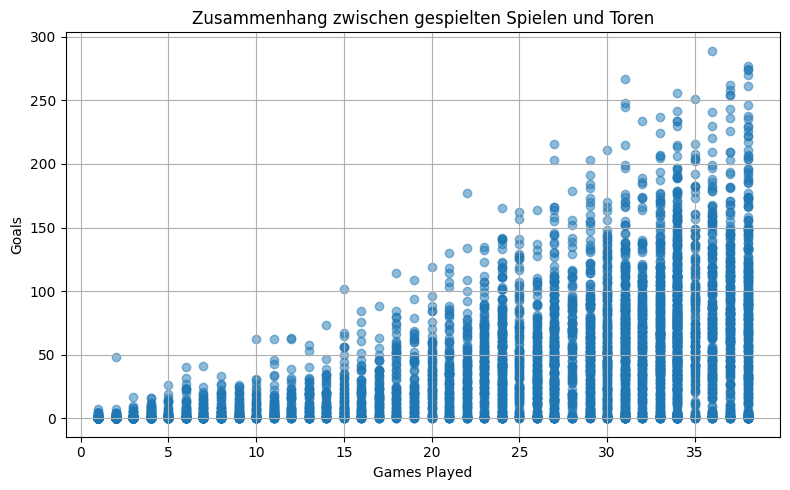

In [8]:
plt.figure(figsize=(8, 5))
plt.scatter(df["Games Played"], df["Goals"], alpha=0.5)
plt.title("Zusammenhang zwischen gespielten Spielen und Toren")
plt.xlabel("Games Played")
plt.ylabel("Goals")
plt.grid(True)
plt.tight_layout()
plt.show()


Die zweite Grafik zeigt die Verteilung der Tore. Damit erkennt man, ob die meisten Spieler eher wenige oder viele Tore erzielen.


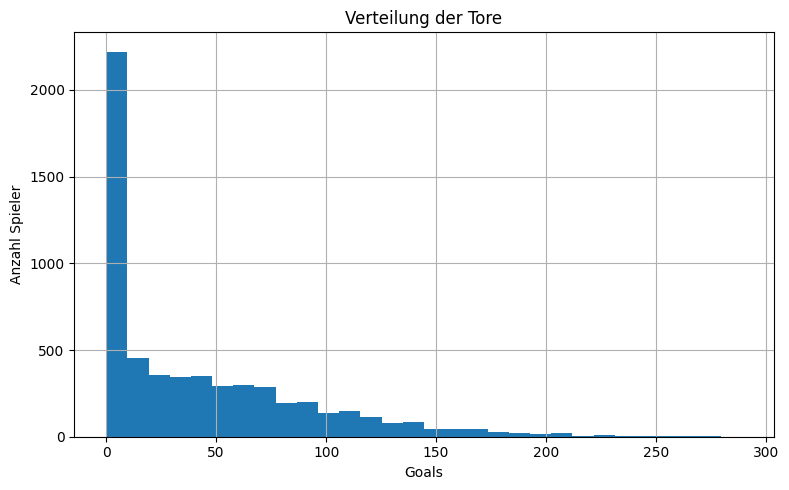

In [9]:
plt.figure(figsize=(8, 5))
plt.hist(df["Goals"], bins=30)
plt.title("Verteilung der Tore")
plt.xlabel("Goals")
plt.ylabel("Anzahl Spieler")
plt.grid(True)
plt.tight_layout()
plt.show()


## 7. Skalierung der Daten

Für viele Machine-Learning-Algorithmen ist Skalierung sinnvoll, weil die numerischen Felder unterschiedliche Wertebereiche haben. Deshalb werden die numerischen Feature-Spalten mit `StandardScaler` standardisiert. Die Zielvariable `Goals` wird hier nicht skaliert, da sie später vorhergesagt werden soll.


In [10]:
scaler = StandardScaler()

df_scaled = df.copy()
df_scaled[feature_cols] = scaler.fit_transform(df_scaled[feature_cols])

display(df_scaled[feature_cols].head())


,Games Played,Missed,Field Goals,Penalty Goals,Assists,Technical Faults,Steals,Blocks,Yellow Cards,2 Min Exclusion,Red Cards,Blue Cards
0,1.071279,5.182466,4.155498,4.725348,1.539533,1.886605,0.886510,0.606274,4.039087,1.501559,1.124500,-0.062961
1,1.236093,2.042979,3.020427,6.821897,-0.059617,0.349026,1.805766,-0.481025,-0.151434,-0.336077,-0.364185,-0.062961
2,1.153686,3.520385,3.382684,4.788880,3.138682,4.159546,3.874092,0.140289,0.546986,0.653419,-0.364185,-0.062961
3,0.988871,5.151687,2.513268,6.631302,2.465356,3.357331,0.197068,0.450946,2.409440,0.936133,-0.364185,-0.062961
4,1.153686,2.196875,2.271763,6.758366,0.361212,1.151241,3.874092,-0.481025,0.314179,-0.477433,-0.364185,-0.062961


In [11]:
scaled_statistics = df_scaled[feature_cols].agg(["mean", "std"]).T.round(2)
display(scaled_statistics)


,mean,std
Games Played,-0.0,1.0
Missed,0.0,1.0
Field Goals,0.0,1.0
Penalty Goals,-0.0,1.0
Assists,-0.0,1.0
Technical Faults,-0.0,1.0
Steals,0.0,1.0
Blocks,-0.0,1.0
Yellow Cards,-0.0,1.0
2 Min Exclusion,0.0,1.0


## 8. Kurzes Fazit

Der Datensatz enthält mehrere numerische Leistungswerte, die für Machine Learning geeignet sind. Als Zielvariable wird `Goals` verwendet, weil Tore eine zentrale Leistungskennzahl im Handball sind und mit anderen Feldern wie `Games Played`, `Assists` oder `Technical Faults` zusammenhängen können. Die Daten wurden kontrolliert, statistisch beschrieben, grafisch untersucht und die numerischen Feature-Spalten wurden skaliert. Für die spätere Modellierung sollte die Spalte `Shooting Accuracy` wegen der unplausiblen Werte nicht verwendet werden.
